# Time-frequency domains in `lisatools`: STFT and WDM

This tutorial presents the two time-frequency analysis domains side by side:

| | **STFT** (short-time Fourier transform) | **WDM** (Wilson–Daubechies–Meyer wavelets) |
|---|---|---|
| Coefficients | complex, per (segment, frequency) | real, per (frequency layer, time pixel) |
| Grid | `NT` segments x `NF` frequencies | `Nf` layers x `Nt` pixels (critically sampled, `N = Nf*Nt`) |
| Resolution knob | segment length `big_dt` | wavelet pixel duration (`Tobs/Nt`) |
| Typical use | drifting sources, noise non-stationarity, cheap transforms | global-fit WDM likelihoods, GB chunked-het machinery |

Two sprint-wide conventions to keep in mind throughout:

1. **Domains are never communicated by strings.** Every transform target is a
   `DomainSettingsBase` child object (`FDSettings`, `STFTSettings`, `WDMSettings`, ...),
   and all dispatch is `isinstance` on those classes.
2. **Everything flows through `TDSignal.transform(settings, window=...)`** — the one
   entry point from the time domain into any analysis domain.

We first build a common test signal, then walk each domain **separately**, and finish
with **side-by-side comparisons over settings**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from lisatools.domains import (
    TDSettings, TDSignal,
    FDSettings,
    STFTSettings, get_stft_settings,
    WDMSettings,
)

## 1. A common time-domain test signal

A linear chirp sweeping through the LISA band plus a monochromatic
(galactic-binary-like) tone — features with very different time-frequency footprints,
so the trade-offs of each basis are visible at a glance. We keep the grid small
(`N = 2**16`, `dt = 5 s`, about 3.8 days) so every cell runs in seconds.

In [2]:
dt = 5.0
N = 2**16
t = np.arange(N) * dt
Tobs = N * dt

f_start, f_end = 2e-3, 2e-2           # chirp sweep (Hz)
f_tone = 8e-3                          # monochromatic tone (Hz)

chirp = np.sin(2 * np.pi * (f_start * t + 0.5 * (f_end - f_start) / Tobs * t**2))
tone = 0.5 * np.sin(2 * np.pi * f_tone * t)
sig = (chirp + tone)[None, :]          # (nchannels=1, N)

# Domain communicated by a settings object -- never a string.
td_settings = TDSettings(N=N, dt=dt, t0=0.0, force_backend="cpu")
td = TDSignal(sig, td_settings)
td

TDSignal(t0=0.0, N=65536, dt=5.0, backend=cpu)

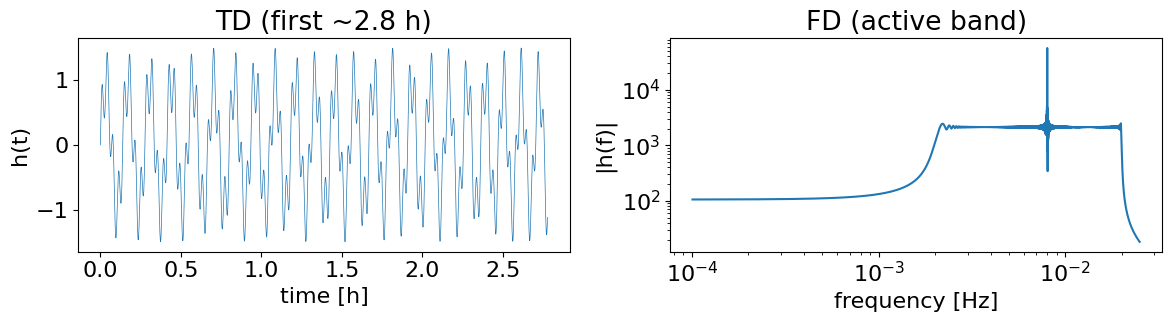

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(t[:2000] / 3600.0, sig[0, :2000], lw=0.5)
axes[0].set_xlabel("time [h]"); axes[0].set_ylabel("h(t)"); axes[0].set_title("TD (first ~2.8 h)")

fd = td.transform(FDSettings(N=N // 2 + 1, df=1 / (N * dt),
                             min_freq=1e-4, max_freq=2.5e-2, force_backend="cpu"))
f_arr = np.asarray(fd.f_arr)
axes[1].loglog(f_arr, np.abs(np.asarray(fd.arr[0])))
axes[1].set_xlabel("frequency [Hz]"); axes[1].set_ylabel("|h(f)|"); axes[1].set_title("FD (active band)")
plt.tight_layout()

The FD view shows the chirp's flat plateau across the sweep band and the sharp
tone at 8 mHz — but no information about *when* each frequency is occupied.
That's what the time-frequency domains add.

## 2. STFT domain

`STFTSettings` describes a grid of `NT` time segments of duration `big_dt`, each
holding `NF = nperseg//2 + 1` frequencies (complex rFFT coefficients). The helper
`get_stft_settings` derives the grid from a time array; the equivalent
`STFTSettings.make_factory(big_dt=..., min_freq=..., max_freq=...)` form is what
global-fit settings files pass as `domain_settings` (the engine calls the factory
with the loaded data's `times`).

In [4]:
big_dt = 64 * dt   # 320 s segments
stft_settings = get_stft_settings(t, big_dt=big_dt,
                                  min_freq=1e-4, max_freq=2.5e-2,
                                  force_backend="cpu")
stft = td.transform(stft_settings)
print(stft)
print("coefficient array (nchannels, NT, NF_active):", stft.arr.shape, stft.arr.dtype)

STFTSignal(t0=0.0, dt=320.0, df=0.003125, NT=1024, NF=33, min_freq=0.0001, max_freq=0.025, backend=cpu)
coefficient array (nchannels, NT, NF_active): (1, 1024, 8) complex128


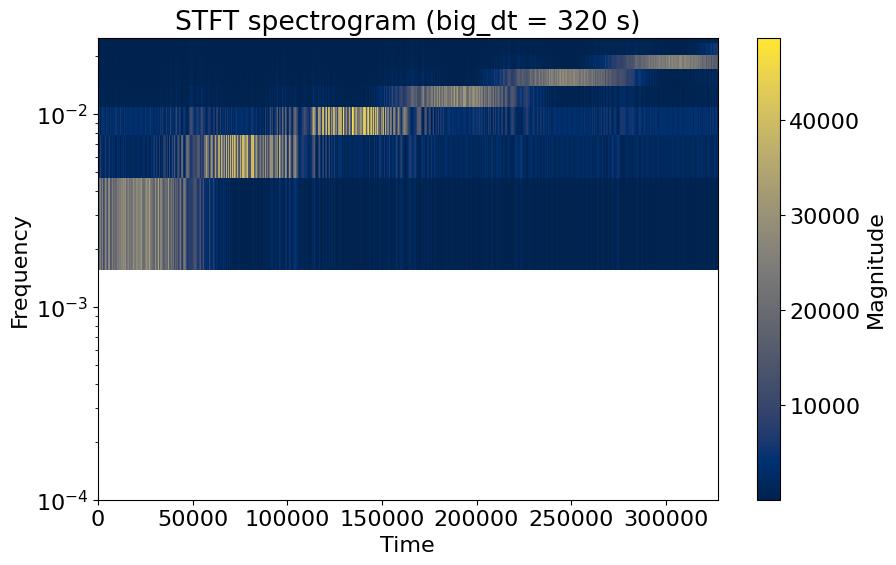

In [5]:
ax = stft._plot_stft(channel=0)
ax.set_title(f"STFT spectrogram (big_dt = {big_dt:.0f} s)");

The chirp appears as the rising track, the tone as the horizontal line.

**Band selection** works through `min_freq` / `max_freq` on the settings: the stored
array only covers the *active* band (`NF_active` bins of the full `NF`), exactly like
`FDSettings.active_slice`.

A Parseval-style check connects total TD power to the STFT coefficients (the small
excess comes from the band edges of the boxcar segmentation):

In [6]:
stft_full = td.transform(get_stft_settings(t, big_dt=big_dt, force_backend="cpu"))
p_td = float(np.sum(sig**2) * dt)
p_stft = float(np.sum(np.abs(np.asarray(stft_full.arr))**2) * 2 * stft_full.df)
print(f"TD power   : {p_td:.6e}")
print(f"STFT power : {p_stft:.6e}   (ratio {p_stft / p_td:.4f})")

TD power   : 2.027967e+05
STFT power : 2.052985e+05   (ratio 1.0123)


> **TODO(post-merge):** the inverse transform `STFTSignal.transform(TDSettings)`
> is not implemented yet — round-tripping STFT -> TD currently raises
> `NotImplementedError`. The forward path is what the likelihoods use.

## 3. WDM wavelet domain

`WDMSettings` describes a critically-sampled wavelet grid: `Nf` frequency layers x
`Nt` time pixels with `Nf * Nt = N` **real** coefficients — same total count as the
TD samples. The layer spacing is `layer_df = 1/(2*Nf*dt)` and the pixel duration is
`Tobs/Nt`. For production grids use `WDMSettings.adjust_to_even_bins` to pick a
wavelet duration that makes both `Nf` and `Nt` even:

In [7]:
nf_e, nt_e, wavelet_dur = WDMSettings.adjust_to_even_bins(
    t_min=3000.0, t_max=5000.0, dt=dt, Tobs=Tobs
)
print(f"adjust_to_even_bins -> Nf={nf_e}, Nt={nt_e}, wavelet duration {wavelet_dur:.0f} s")

# For the demo we keep the exact power-of-two grid (Nf * Nt == N):
Nf = 64
Nt = N // Nf
wdm_settings = WDMSettings(Nf=Nf, Nt=Nt, dt=dt, force_backend="cpu")
wdm = td.transform(wdm_settings)
print(wdm)
print("coefficient array (nchannels, Nf, Nt):", wdm.arr.shape, wdm.arr.dtype)

adjust_to_even_bins -> Nf=602, Nt=108, wavelet duration 3010 s
WDMSignal(Tobs=327680.0, dt=5.0, t0=0.0, Nt=1024, Nf=64, oversample=16, backend=cpu)
coefficient array (nchannels, Nf, Nt): (1, 64, 1024) float64


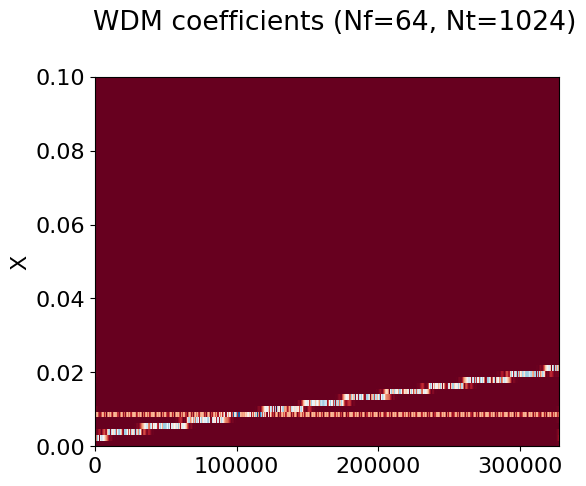

In [8]:
fig, _ = wdm.heatmap(mag=True)
fig.suptitle(f"WDM coefficients (Nf={Nf}, Nt={Nt})", y=1.02);

Same picture, different basis: the chirp track and the constant tone — but the
coefficients are *real* and the grid is critically sampled (no redundancy), which is
why the global-fit WDM likelihood can treat each (layer, pixel) as an independent
datum with a per-pixel noise value.

> **TODO(post-merge):** `WDMSignal.transform(TDSettings)` (inverse to TD) currently
> hits a broadcast bug in the `wdm_to_fd -> ifft` chain; the forward path and the
> WDM-domain likelihood machinery are unaffected.

## 4. Side-by-side: resolution trade-offs over settings

Both bases trade time against frequency resolution through one knob:
segment length `big_dt` (STFT) and the wavelet pixel duration `Tobs/Nt`
(equivalently `Nf`, since `Nt = N/Nf`). We sweep three matched values of each —
note `big_dt = 2 * Nf * dt` gives the two bases the same time resolution.

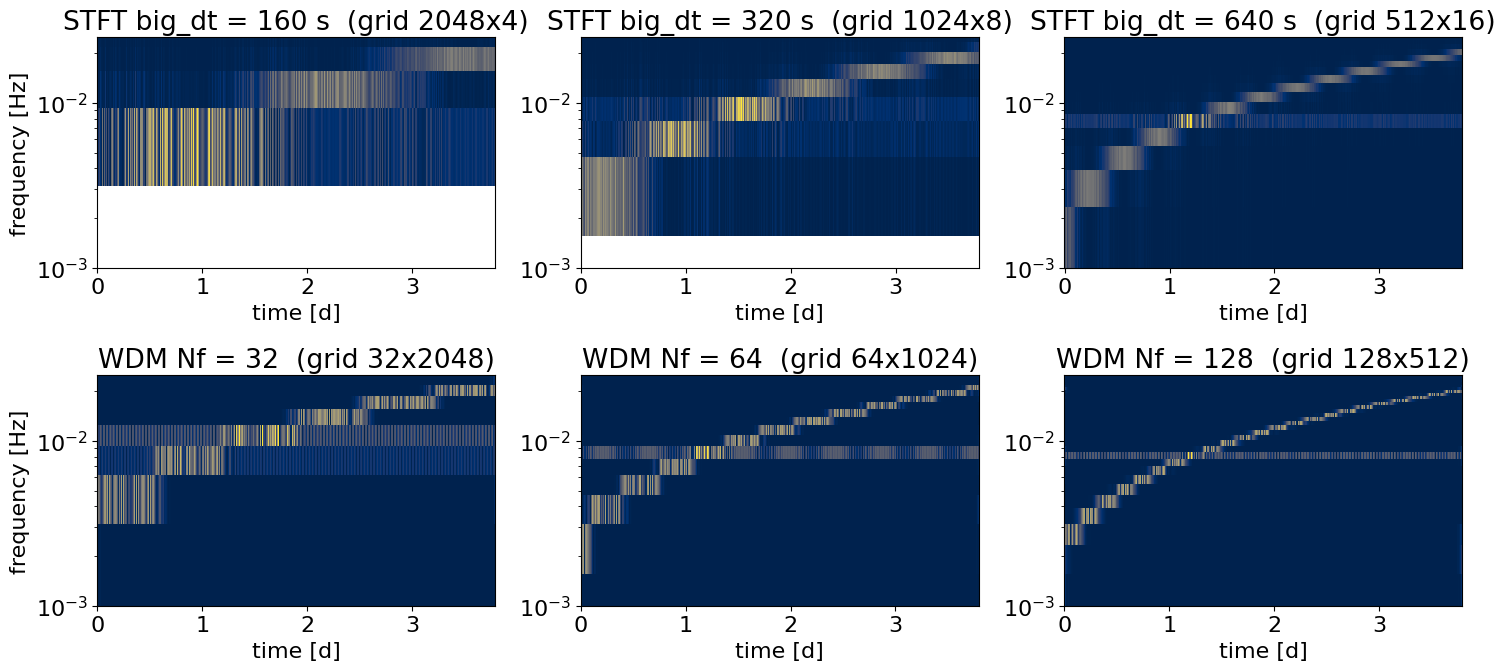

In [9]:
facs = (32, 64, 128)   # STFT nperseg; matched WDM Nf = nperseg/2... we sweep Nf directly
nfs = (32, 64, 128)

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=False)
for j, fac in enumerate(facs):
    s = td.transform(get_stft_settings(t, big_dt=fac * dt,
                                       min_freq=1e-4, max_freq=2.5e-2,
                                       force_backend="cpu"))
    arr = np.abs(np.asarray(s.arr[0])) ** 2
    t_seg = np.asarray(s.t_arr) / 86400.0
    f_seg = np.asarray(s.f_arr)
    pc = axes[0, j].pcolormesh(t_seg, f_seg, arr.T, shading="auto", cmap="cividis")
    axes[0, j].set_yscale("log"); axes[0, j].set_ylim(1e-3, 2.5e-2)
    axes[0, j].set_title(f"STFT big_dt = {fac * dt:.0f} s  (grid {s.arr.shape[1]}x{s.arr.shape[2]})")
    axes[0, j].set_xlabel("time [d]")
axes[0, 0].set_ylabel("frequency [Hz]")

for j, nf in enumerate(nfs):
    w = td.transform(WDMSettings(Nf=nf, Nt=N // nf, dt=dt, force_backend="cpu"))
    arr = np.abs(np.asarray(w.arr[0]))
    layer_f = (np.arange(nf) + 0.5) / (2 * nf * dt)
    pix_t = (np.arange(N // nf) + 0.5) * (Tobs / (N // nf)) / 86400.0
    axes[1, j].pcolormesh(pix_t, layer_f, arr, shading="auto", cmap="cividis")
    axes[1, j].set_yscale("log"); axes[1, j].set_ylim(1e-3, 2.5e-2)
    axes[1, j].set_title(f"WDM Nf = {nf}  (grid {nf}x{N // nf})")
    axes[1, j].set_xlabel("time [d]")
axes[1, 0].set_ylabel("frequency [Hz]")
plt.tight_layout()

Reading across each row: short segments / few layers (left) resolve the chirp's
*time* evolution sharply but smear frequencies; long segments / many layers (right)
pin the tone's *frequency* but blur when the chirp passes through. The WDM row shows
the same trade-off with real coefficients on the critically-sampled grid.

### Coefficient bookkeeping

| basis | grid | values per (t,f) cell | total real numbers |
|---|---|---|---|
| STFT (full band) | `NT x NF` | 1 complex = 2 real | `2 * NT * NF ~ N + 2*NT` |
| WDM | `Nf x Nt` | 1 real | `Nf * Nt = N` exactly |

## 5. Where this plugs into the global fit

- `GeneralSettings(domain_settings=...)` takes a **settings object or factory**:
  `STFTSettings.make_factory(big_dt=..., min_freq=..., max_freq=...)`,
  `FDSettings.make_factory(min_freq=..., max_freq=...)`, or
  `WDMSettings.make_factory(Nf=..., Nt=..., ...)`. The engine resolves the factory
  against the loaded data's time grid and every downstream consumer dispatches on
  the settings class.
- Waveform wrappers project to the run's domain through the same machinery
  (`TDWaveformBase(output_domain_settings=...)` -> full-grid placement ->
  `TDSignal.transform`).
- For deeper WDM material (wavelet construction, likelihoods, sparse/chunked
  machinery) see `wdm_transform_tutorial.ipynb` alongside this notebook.